In [31]:
import cv2                          
import numpy as np                  
import matplotlib.pyplot as plt     

In [32]:
def load_and_prepare_image(image_path):
    img_color = cv2.imread(image_path)                     
    if img_color is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")


    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)  
    return img_color, img_gray                                 

# SIFT

In [33]:
def detect_and_compute_sift(gray_img):
    sift = cv2.SIFT_create()                            # Create SIFT detector object (OpenCV ≥4.4)
    # You can tune parameters: nfeatures, nOctaveLayers, contrastThreshold, etc.
    # sift = cv2.SIFT_create(nfeatures=500, contrastThreshold=0.04)

    keypoints, descriptors = sift.detectAndCompute(gray_img, None)
    # detectAndCompute() does both detection + description in one call
    # None = no mask (use whole image)

    return keypoints, descriptors

# ORB

In [34]:
def detect_and_compute_orb(gray_img, nfeatures=1500):
    orb = cv2.ORB_create(nfeatures=nfeatures)           # Limit max number of features
    # Other useful params: scaleFactor=1.2, nlevels=8, edgeThreshold=31, scoreType=cv2.ORB_HARRIS_SCORE

    keypoints, descriptors = orb.detectAndCompute(gray_img, None)
    # Returns: list of KeyPoint objects + binary descriptor array (uint8)

    return keypoints, descriptors

# SURF

In [35]:
def detect_and_compute_surf(gray_img):
    try:
        surf = cv2.xfeatures2d.SURF_create()            # SURF is in xfeatures2d module
        # surf.setExtended(1)                           # Optional: 128-dim instead of 64
        # surf.setHessianThreshold(400)

        keypoints, descriptors = surf.detectAndCompute(gray_img, None)
        return keypoints, descriptors
    except AttributeError:
        print("SURF is not available in this OpenCV build (patented / non-free).")
        print("Use SIFT or ORB instead for this demonstration.")
        return [], None
    except cv2.error as e:
        print("SURF error:", e)
        print("Likely need to compile OpenCV with non-free flag.")
        return [], None

In [36]:
def draw_keypoints(img_color, keypoints, title="Keypoints"):
    """
    Draw detected keypoints on the color image for visualization.
    """
    img_with_kp = cv2.drawKeypoints(
        img_color,
        keypoints,
        None,                                   # output image (None = create new)
        color=(0, 255, 0),                      # green circles
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        # shows orientation & scale
    )
    # Show using matplotlib (handles RGB conversion)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

Image loaded: (993, 1000)

Computing SIFT...
SIFT → 1435 keypoints found


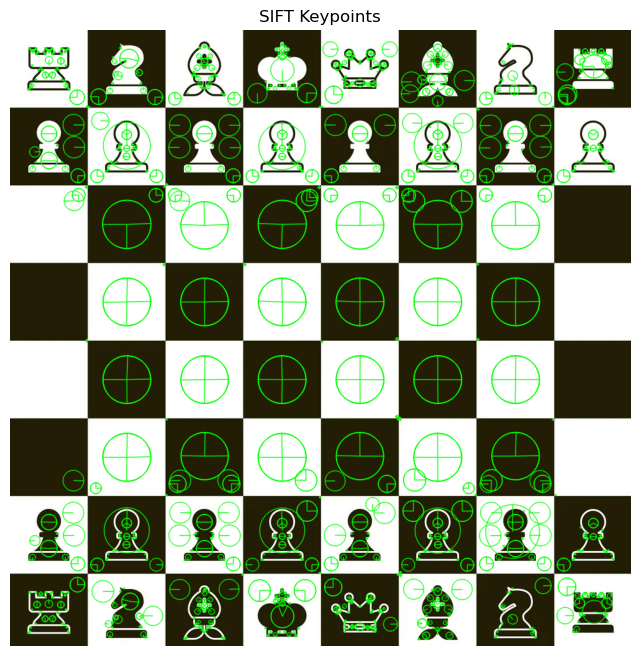


Computing ORB...
ORB  → 2000 keypoints found


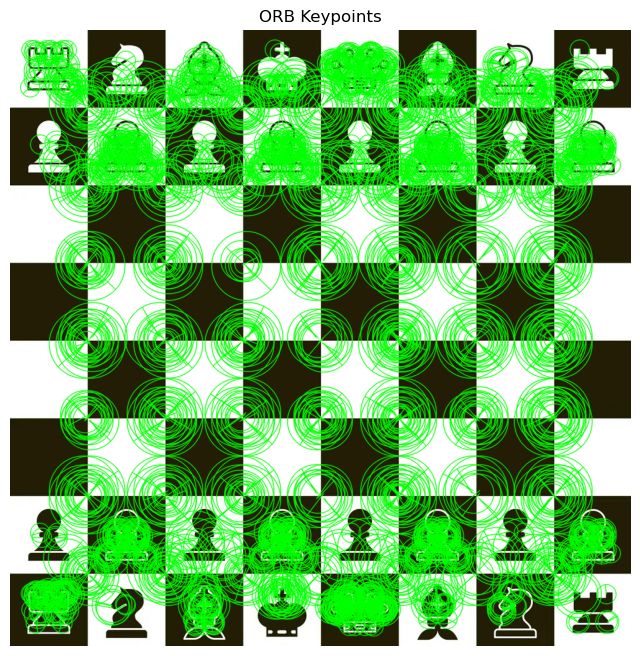


Trying SURF (may not be available)...
SURF is not available in this OpenCV build (patented / non-free).
Use SIFT or ORB instead for this demonstration.
Skipping SURF visualization.


In [37]:
def main():
  image_path = "chess-board.jpg"          
  color_img, gray_img = load_and_prepare_image(image_path)
  print(f"Image loaded: {gray_img.shape}")

  print("\nComputing SIFT...")
  kp_sift, des_sift = detect_and_compute_sift(gray_img)
  print(f"SIFT → {len(kp_sift)} keypoints found")

  if kp_sift:
    draw_keypoints(color_img, kp_sift, "SIFT Keypoints")

  print("\nComputing ORB...")
  kp_orb, des_orb = detect_and_compute_orb(gray_img, nfeatures=2000)
  print(f"ORB  → {len(kp_orb)} keypoints found")

  if kp_orb:
    draw_keypoints(color_img, kp_orb, "ORB Keypoints")

  print("\nTrying SURF (may not be available)...")
  kp_surf, des_surf = detect_and_compute_surf(gray_img)
  if kp_surf:
      print(f"SURF → {len(kp_surf)} keypoints found")
      draw_keypoints(color_img, kp_surf, "SURF Keypoints")
  else:
      print("Skipping SURF visualization.")

# Call the main function to execute the image processing workflow
main()

# Task :
* Feature matching between two images
* BFMatcher + ratio test
* drawMatches visualization

In [38]:
image_path_2 = "chess_board2.jpg" # Define the path for the second image using an available file
color_img2, gray_img2 = load_and_prepare_image(image_path_2)
print(f"Second image loaded: {gray_img2.shape}")

Second image loaded: (2000, 2000)


In [40]:
image_path_1 = "chess-board.jpg"
color_img1, gray_img1 = load_and_prepare_image(image_path_1)

print("\nComputing SIFT for first image...")
kp_sift1, des_sift1 = detect_and_compute_sift(gray_img1)
print(f"SIFT (Image 1) → {len(kp_sift1)} keypoints found")


Computing SIFT for first image...
SIFT (Image 1) → 1435 keypoints found


In [41]:
print("\nComputing SIFT for second image...")
kp_sift2, des_sift2 = detect_and_compute_sift(gray_img2)
print(f"SIFT (Image 2) → {len(kp_sift2)} keypoints found")


Computing SIFT for second image...
SIFT (Image 2) → 29262 keypoints found


In [42]:
def bf_matcher_ratio_test(des1, des2):
    # 1. Instantiate a cv2.BFMatcher object.
    # SIFT uses floating-point descriptors, so NORM_L2 is appropriate.
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

    # 2. Use knnMatch() to find the 2 best matches for each descriptor.
    # It returns k=2 nearest neighbors.
    matches = matcher.knnMatch(des1, des2, k=2)

    # 3. Apply Lowe's ratio test.
    good_matches = []
    # Ensure there are at least two matches for ratio test
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # 4. Return the list of good matches.
    return good_matches


# Perform matching for SIFT descriptors
good_matches_sift = bf_matcher_ratio_test(des_sift1, des_sift2)
print(f"Found {len(good_matches_sift)} good matches using SIFT and Ratio Test.")

Found 44 good matches using SIFT and Ratio Test.


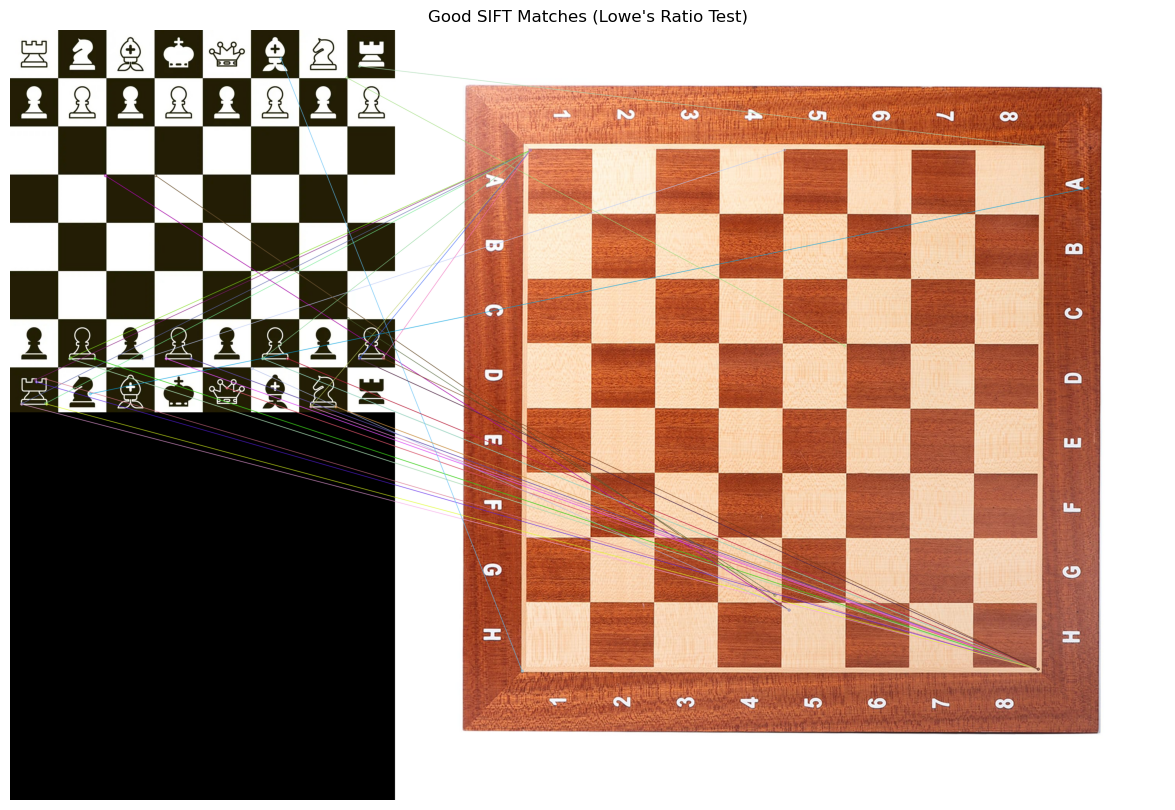

In [44]:
matched_img = cv2.drawMatches(
    color_img1,
    kp_sift1,
    color_img2,
    kp_sift2,
    good_matches_sift,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Good SIFT Matches (Lowe's Ratio Test)")
plt.axis('off')
plt.show()